In [1]:
import sys
import os

backend_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if backend_path not in sys.path:
    sys.path.insert(0, backend_path)

print(f"Backend path: {backend_path}")
print("Ready ✅")

Backend path: /home/rishabh/Documents/AI Projects
Ready ✅


In [2]:
from ml.src.train import generate_training_data
import pandas as pd

df = generate_training_data()
print(f'Total samples: {len(df)}')
print(f'Positive (Match): {df["label"].sum()}')
print(f'Negative (No Match): {len(df) - df["label"].sum()}')
df.head()

/home/rishabh/.local/lib/python3.10/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/rishabh/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):


Total samples: 12
Positive (Match): 6
Negative (No Match): 6


,resume,job,label
0,5 years Python FastAPI PostgreSQL Docker AWS R...,Python developer FastAPI PostgreSQL Docker AWS,1
1,React JavaScript TypeScript NodeJS MongoDB 3 y...,Frontend developer React JavaScript TypeScript,1
2,Java Spring Boot Kubernetes microservices 7 years,Java backend Spring Boot Kubernetes microservices,1
3,Data scientist Python pandas numpy scikit-lear...,Data scientist machine learning Python scikit-...,1
4,DevOps AWS Docker Kubernetes Jenkins Linux 6 y...,DevOps engineer AWS Docker Kubernetes Jenkins,1


In [3]:
import numpy as np
from app.ml.models.similarity import SimilarityModel

sim_model = SimilarityModel()
X, y = [], []

for i, row in df.iterrows():
    print(f'Processing {i+1}/{len(df)}...')
    vec = sim_model.feature_vector(row['resume'], row['job'])
    X.append(vec[0])
    y.append(row['label'])

X = np.array(X)
y = np.array(y)
print(f'\nFeature matrix: {X.shape}')
print('Features: semantic, skill_match, experience, word_overlap, resume_skills, job_skills, matched_skills')

Loading embedder: all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Processing 1/12...
Processing 2/12...
Processing 3/12...
Processing 4/12...
Processing 5/12...
Processing 6/12...
Processing 7/12...
Processing 8/12...
Processing 9/12...
Processing 10/12...
Processing 11/12...
Processing 12/12...

Feature matrix: (12, 7)
Features: semantic, skill_match, experience, word_overlap, resume_skills, job_skills, matched_skills


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from app.ml.models.classifier import MatchClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

classifier = MatchClassifier(model_type='xgboost')
classifier.train(X_train, y_train)

y_pred = classifier.model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'\nAccuracy: {acc:.3f}')
print(classification_report(
    y_test, y_pred,
    target_names=['No Match','Match'],
    zero_division=0
))

Train: (9, 7), Test: (3, 7)

Accuracy: 0.333
              precision    recall  f1-score   support

    No Match       0.00      0.00      0.00         2
       Match       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



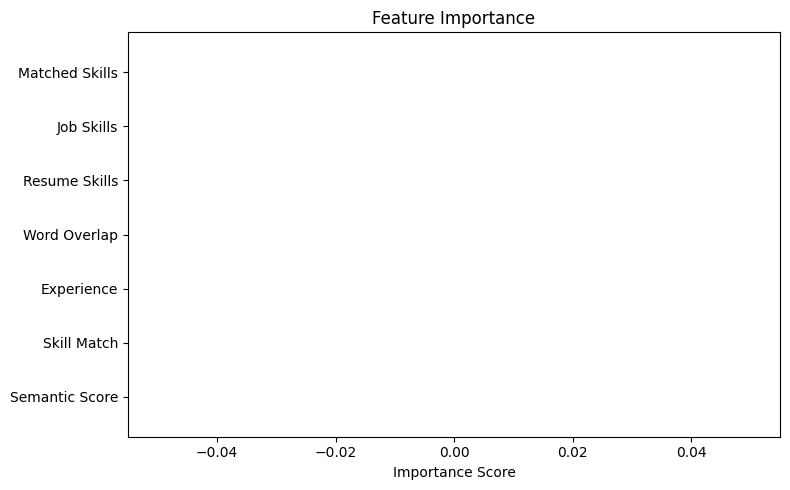

In [5]:
import matplotlib.pyplot as plt
import numpy as np

feature_names = [
    'Semantic Score', 'Skill Match', 'Experience',
    'Word Overlap', 'Resume Skills', 'Job Skills', 'Matched Skills'
]
importances = classifier.model.feature_importances_
sorted_idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    [feature_names[i] for i in sorted_idx],
    [importances[i] for i in sorted_idx],
    color='steelblue'
)
ax.set_title('Feature Importance')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [6]:
classifier.save()
print('\n✅ Model saved to app/ml/artifacts/model.pkl')
print('Training Complete ✅')

Model saved → /home/rishabh/Documents/AI Projects/AI Resume Matcher/backend/app/ml/models/../artifacts/model.pkl

✅ Model saved to app/ml/artifacts/model.pkl
Training Complete ✅
